# Loan Approval Prediction Using Machine Learning

## Overview
This project predicts whether a loan application willl be approved or rejected based on applicant information such as income, eductaion, loan amount, credit, history, and other factors. It is binary classifictaion problem where the target variable is **Loan_Status**.

## Objective

- Predict loan approval status.
- Perform data preprocessing.
- Handle missing values.
- Train a classification model.
- Evaluate model performance.

##Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score




## Load Dataset

In [3]:
train_data = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')
test_data = pd.read_csv('test_Y3wMUE5_7gLdaTN.csv')

## Display First Five Rows

In [4]:
train_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Dataset Information

In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


## Statistical Summary

In [6]:
train_data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


## Check Missing Values

In [7]:
train_data.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


## Handle Missing Values

In [8]:
train_data["Gender"].fillna(train_data["Gender"].mode()[0], inplace=True)
train_data["Married"].fillna(train_data["Married"].mode()[0], inplace=True)
train_data["Dependents"].fillna(train_data["Dependents"].mode()[0], inplace=True)
train_data["Self_Employed"].fillna(train_data["Self_Employed"].mode()[0], inplace=True)
train_data["LoanAmount"].fillna(train_data["LoanAmount"].median(), inplace=True)
train_data["Loan_Amount_Term"].fillna(train_data["Loan_Amount_Term"].mode()[0], inplace=True)
train_data["Credit_History"].fillna(train_data["Credit_History"].mode()[0], inplace=True)

/tmp/ipykernel_933/4073989431.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data["Gender"].fillna(train_data["Gender"].mode()[0], inplace=True)
/tmp/ipykernel_933/4073989431.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(valu

## Verify Missing Values

In [9]:
train_data.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


## Exploratory Data Analysis (EDA)

### Distribution of Loan Status

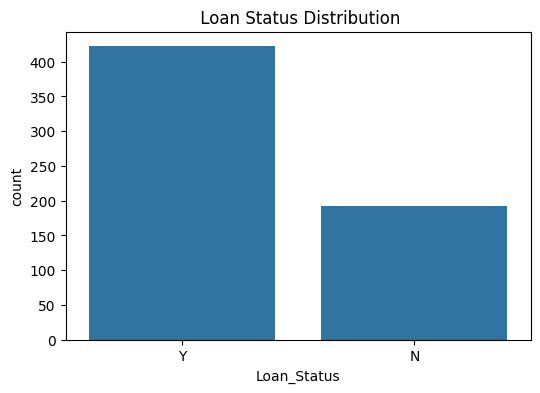

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=train_data)
plt.title(' Loan Status Distribution')
plt.show()

### Distribution of Gender

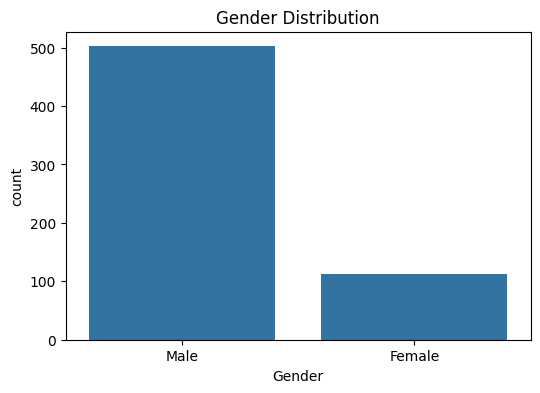

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=train_data)
plt.title('Gender Distribution')
plt.show()

### Distribution of Education

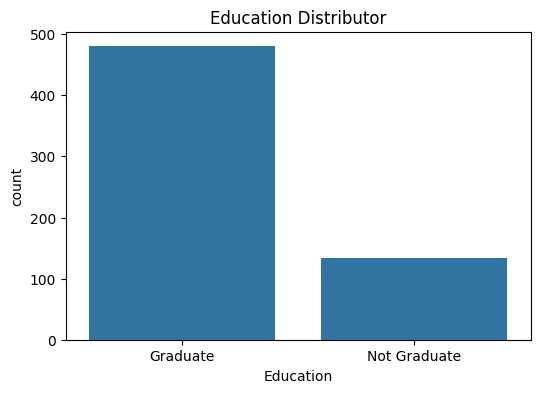

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='Education', data=train_data)
plt.title('Education Distributor')
plt.show()

### Distribution of Property Area

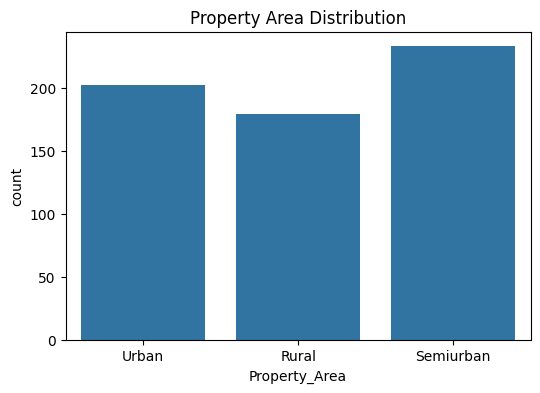

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='Property_Area', data=train_data)
plt.title('Property Area Distribution')
plt.show()

### Correlation Heatmap

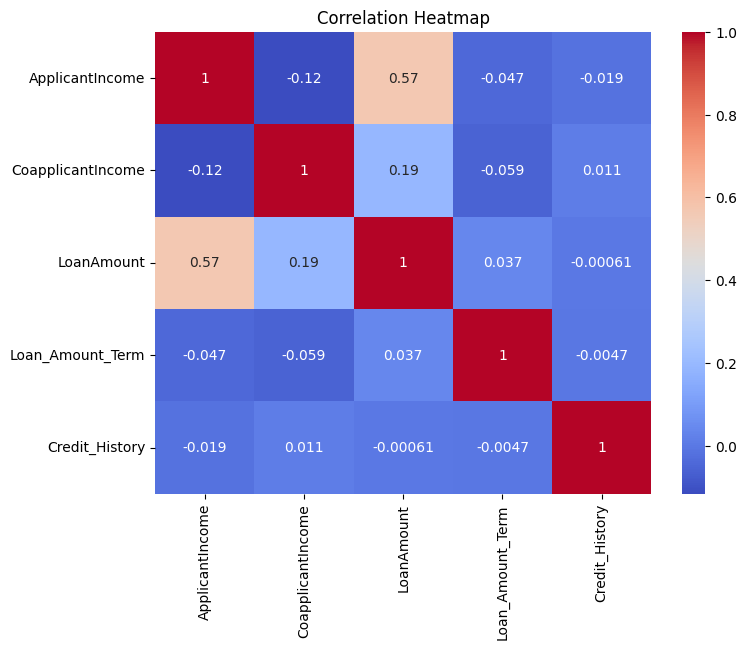

In [14]:
numeric_data = train_data.select_dtypes(include=['number'])

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Data Preprocessing

### Encoding Categorical Variables

In [15]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_columns = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]

for column in categorical_columns:
    train_data[column] = label_encoder.fit_transform(train_data[column])

## Feature Selection

In [16]:
X = train_data.drop(columns=['Loan_ID', 'Loan_Status'])
y = train_data['Loan_Status']

## Split the Dataset

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train the Model

In [18]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Model Prediction

In [19]:
y_pred = model.predict(X_test)

## Model Accuracy

In [20]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7560975609756098


## Confusion Matrix

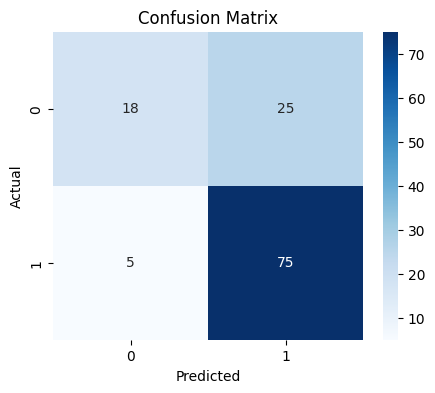

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Classification Report

In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.42      0.55        43
           1       0.75      0.94      0.83        80

    accuracy                           0.76       123
   macro avg       0.77      0.68      0.69       123
weighted avg       0.76      0.76      0.73       123



In [23]:
test_data = pd.get_dummies(test_data)
test_data = test_data.reindex(columns=X_train.columns, fill_value=0)

## Predict on Test Dataset

In [24]:


test_predictions = model.predict(test_data)

print(test_predictions[:10])

[1 1 1 1 0 1 0 0 1 1]


In [25]:
print(test_data.columns)

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')


In [26]:
print(X_train.columns)

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')


## Feature Importance

In [27]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
9,Credit_History,0.262914
5,ApplicantIncome,0.202666
7,LoanAmount,0.185022
6,CoapplicantIncome,0.113861
8,Loan_Amount_Term,0.051443
10,Property_Area,0.049602
2,Dependents,0.048141
1,Married,0.023648
3,Education,0.021271
0,Gender,0.020718


## Feature Importance Visualization

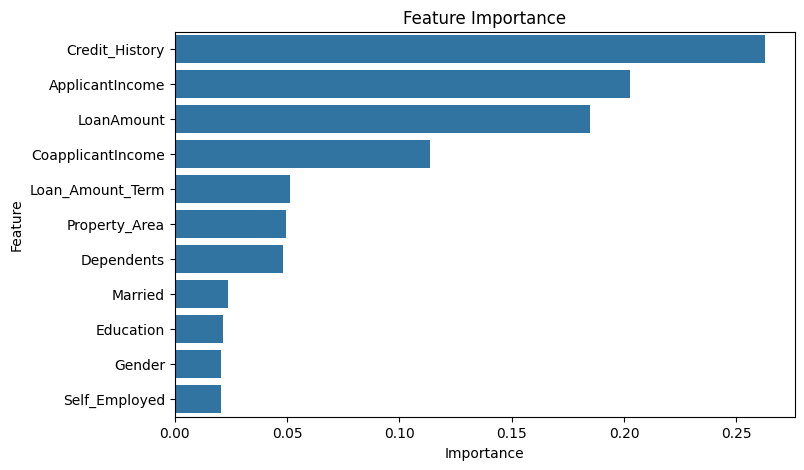

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance")
plt.show()

## Save Trained Model

In [29]:
import joblib

joblib.dump(model, "loan_approval_model.pkl")

print("Model saved successfully!")

Model saved successfully!


## Hyperparameter Tuning

In [30]:
from sklearn.ensemble import RandomForestClassifier

tuned_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

tuned_model.fit(X_train, y_train)

tuned_predictions = tuned_model.predict(X_test)

tuned_accuracy = accuracy_score(y_test, tuned_predictions)

print("Tuned Model Accuracy:", tuned_accuracy)

Tuned Model Accuracy: 0.7642276422764228


## Model Comparison

In [31]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Tuned Random Forest"],
    "Accuracy": [accuracy, tuned_accuracy]
})

comparison

,Model,Accuracy
0,Random Forest,0.756098
1,Tuned Random Forest,0.764228


## Future Scope

This project can be further improved by using advanced machine learning algorithms, hyperparameter optimization, feature engineering, and deployment through Streamlit or Flask. Future versions can also include real-time loan prediction using a web application.

## Conclusion

This project successfully predicts loan approval status using a Random Forest Classifier. The dataset was preprocessed by handling missing values and encoding categorical features. Exploratory Data Analysis (EDA) was performed to understand the data distribution, and the model achieved good prediction performance. This project demonstrates the complete machine learning workflow, from data preprocessing to model evaluation and prediction.